# Plotting light curves

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
def getting_light_curves(path="light_curves/object_light_curves_old/"):
    files = glob.glob(path+"*.data")
    dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}).loc[lambda df: df['Error'].notna()] for f in files}
    
    return dfs

def plotting_light_curves(ax,df,name,color,error_multiplier=1):
    ax.errorbar(df['Julian_Date'], df['Flux'], yerr=error_multiplier*df['Error'], fmt='.',color=color, label=name)
    ax.set_title(f'Light Curve: {name}')
    ax.set_xlabel('Julian Date')
    ax.set_ylabel('Flux')
    ax.legend()


dfs=getting_light_curves()
keys=['lc4735.data', 'lc5089.data', 'lc669.data', 'lc932.data']
sorted_keys = sorted(keys, key=lambda x: int(x[2:-5]))
dfs = {k: dfs[k] for k in sorted_keys}
fig,ax=plt.subplots(4,figsize=(10,15),layout='constrained')
colors_viridis=plt.cm.viridis(np.linspace(0,1,len(ax)))

for i,(name,df) in enumerate(dfs.items()):
    plotting_light_curves(ax[i],df,name,color=colors_viridis[i])




KeyError: 'lc669.data'

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/2262000258.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}).loc[lambda df: df['Error'].notna()] for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/2262000258.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}).loc[lambda df: df['Error'].notna()] for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/2262000258.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.re

dict_keys(['ang_event_i.data', 'ang_event_ii.data', 'ang_event_iii.data', 'ang_event_iv.data'])
dict_keys(['lc669.data', 'lc932.data', 'lc4735.data', 'lc5089.data'])
4


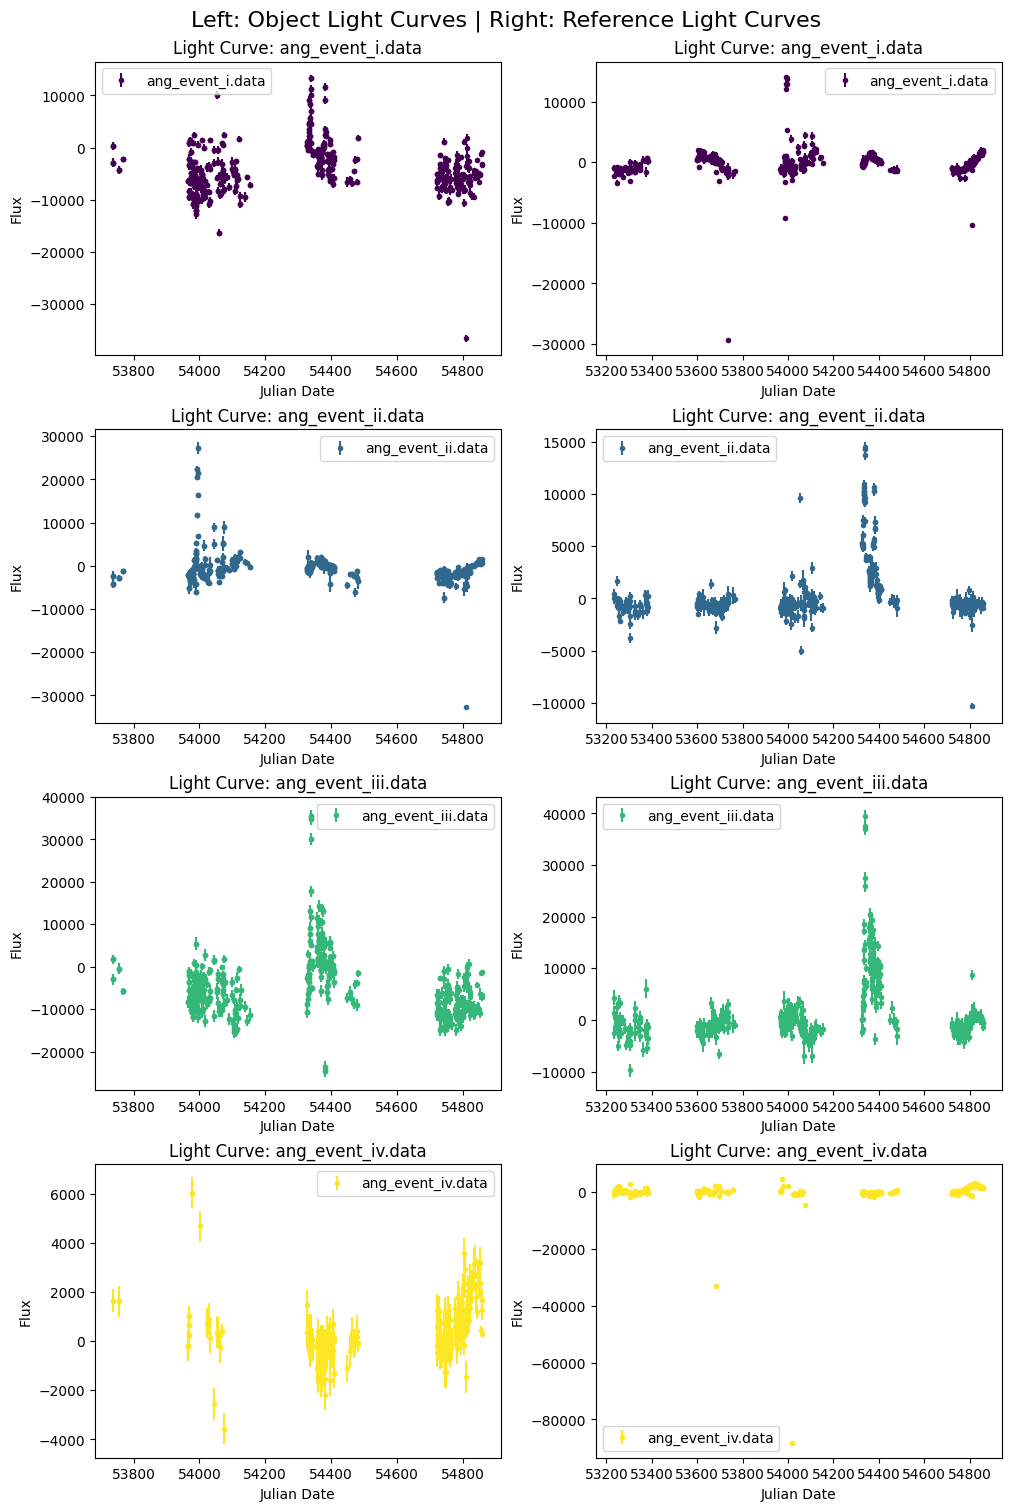

In [ ]:
dfs=getting_light_curves()
dfs_reference=getting_light_curves("reference_light_curves/")
ordered_keys = sorted(dfs_reference.keys())
ordered_reference_dfs = {k:dfs_reference[k] for k in ordered_keys}
print(ordered_reference_dfs.keys())
keys=['lc4735.data', 'lc5089.data', 'lc669.data', 'lc932.data']
sorted_keys = sorted(keys, key=lambda x: int(x[2:-5]))
dfs = {k: dfs[k] for k in sorted_keys}
print(dfs.keys())
ig,ax=plt.subplots(4,2,figsize=(10,15),layout='constrained')
print(len(ax[:,0]))
colors_viridis=plt.cm.viridis(np.linspace(0,1,len(ax[:,0])))
plt.suptitle('Left: Object Light Curves | Right: Reference Light Curves', fontsize=16)

for i,((name1,df1),(name2,df_ref)) in enumerate(zip(dfs.items(),ordered_reference_dfs.items())):
    plotting_light_curves(ax[i][0],df1,name2,color=colors_viridis[i])
    plotting_light_curves(ax[i][1],df_ref,name2,color=colors_viridis[i])



# Fitting to PSF model

using the micro-1-2.param parameters we can fit the curves from ogle.

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/3131853698.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/3131853698.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}


Fitted parameters for micro-2.dat:t_0,u_0,t_E,M_PSF,F_b [2.45455042e+06 2.68407067e-02 2.00123585e+01 1.86248922e+01
 8.57957092e-01]
errors: [0.00506234 0.00069941 0.41611398 0.00140387 0.02077261]
Chi-squared for micro-2.dat: 2512.616405099921, Reduced Chi-squared: 2.03946136777591

Fitted parameters for micro-1.dat:t_0,u_0,t_E,M_PSF,F_b [2.45453929e+06 6.32834266e-02 2.06305252e+01 1.88914083e+01
 5.48816443e-01]
errors: [0.01728895 0.0051126  1.35521133 0.00224829 0.04509   ]
Chi-squared for micro-1.dat: 1407.2114354255955, Reduced Chi-squared: 1.8110829284756698



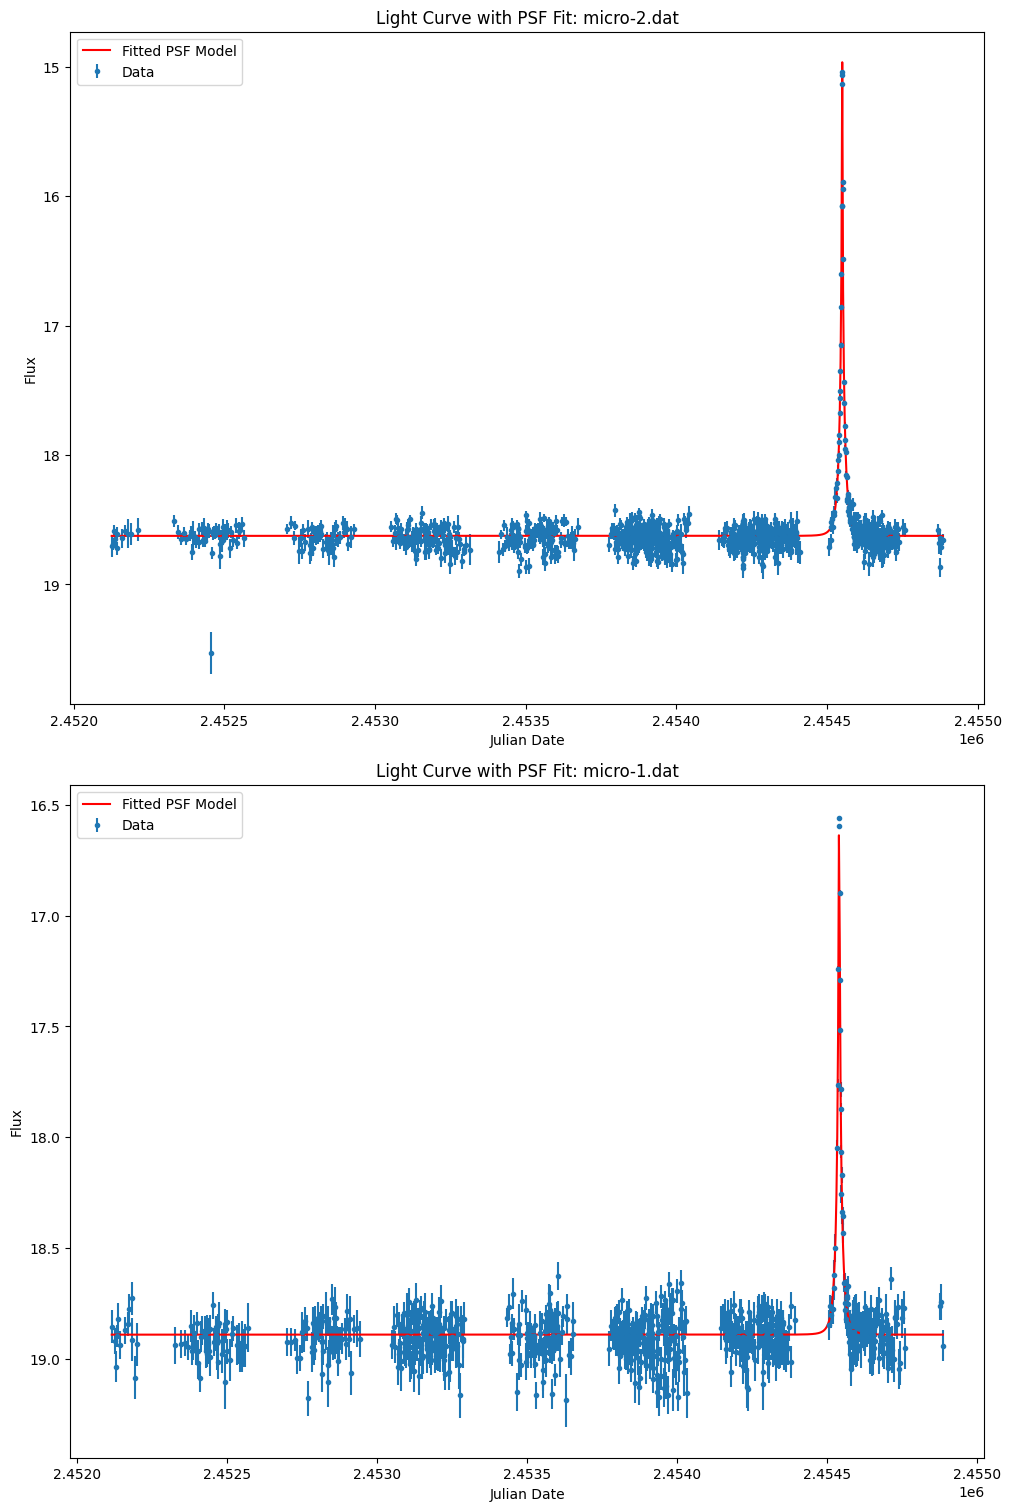

In [ ]:
from scipy.optimize import curve_fit
def PSF(t,t_0,u_0,t_E,M_psf,F_b):
    """Point Source Point Lens model for microlensing light curves."""
    u = np.sqrt(u_0**2 + ((t-t_0)/t_E)**2)
    A = (u**2 + 2) / (u * np.sqrt(u**2 + 4))
    M=M_psf-2.5 * np.log10(F_b*A+(1-F_b))
    return M

def getting_light_curves_2(path="light_curves/object_light_curves/"):
    files = glob.glob(path+"*.dat")
    dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}) for f in files}
    return dfs


def chi_squared(observed, expected, error):
    return np.sum(((observed - expected) / error) ** 2)

dfs=getting_light_curves_2('ogle_light_curves/')
fig,ax=plt.subplots(2,figsize=(10,15),layout='constrained')
p_0=[[
    2454550.424,     # t_0: event time ~ middle of dataset
    0.027,                          # u_0: impact parameter, small but >0
    37.270,                           # t_E: Einstein radius crossing time (days)
    18.791,  # F_s: source flux
    0.124        # F_b: blended flux
],
[
    2454539.289,     # t_0: event time ~ middle of dataset
    0.063,                          # u_0: impact parameter, small but >0
    15.823,                           # t_E: Einstein radius crossing time (days)
    19.543,  # F_s: source flux
    0.451        # F_b: blended flux
]]
for i,(name,df) in enumerate(dfs.items()):
    p0=p_0[i]
    try:
        ax[i].yaxis.set_inverted(True)
        t_fit = np.linspace(df['Julian_Date'].min(), df['Julian_Date'].max(), 1000)
        popt, pcov = curve_fit(PSF, df['Julian_Date'], df['Flux'], p0=p0,sigma=df['Error'], absolute_sigma=True, maxfev=10000)
        ax[i].errorbar(df['Julian_Date'], df['Flux'], yerr=df['Error'], fmt='.', label='Data')
        ax[i].plot(t_fit, PSF(t_fit, *popt), 'r-', label='Fitted PSF Model')
        ax[i].set_title(f'Light Curve with PSF Fit: {name}')
        ax[i].set_xlabel('Julian Date')
        ax[i].set_ylabel('Flux')
        ax[i].legend()
        print(f"Fitted parameters for {name}:t_0,u_0,t_E,M_PSF,F_b {popt}")
        print('errors:', np.sqrt(np.diag(pcov)))
        chi_squared_total=0
        for j in df.index:
            chi = chi_squared(df['Flux'][j], PSF(df['Julian_Date'][j], *popt), df['Error'][j])
            chi_squared_total += chi
        print(f"Chi-squared for {name}: {chi_squared_total}, Reduced Chi-squared: {chi_squared_total / (len(df) - len(popt))}\n")

    except RuntimeError as e:
        print(f"Could not fit data for {name}: {e}")
    

# Degenerate flux fix

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/3926067555.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}).loc[lambda df: df['Error'].notna()] for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/3926067555.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dfs = {os.path.basename(f): pd.read_csv(f, delim_whitespace=True, header=None).drop(columns=[3,4,5]).rename(columns={0:'Julian_Date',1:'Flux',2:'Error'}).loc[lambda df: df['Error'].notna()] for f in files}
/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_66620/3926067555.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.re

Fitted parameters for lc932.data:
 t_0, delta_F_0, F_base, t_half [ 5.39936546e+04 -3.07913238e+04  3.28885769e+02  2.05446242e+00]
errors: [6.23671334e-03 1.16459385e+03 1.58493985e+01 9.03532128e-02]
Chi-squared for lc932.data: 10473.430442868372, Reduced Chi-squared: 16.94729845124332

Fitted parameters for lc669.data:
 t_0, delta_F_0, F_base, t_half [54312.66528621 -6113.30562305  3783.31539536   179.38284213]
errors: [  3.2798728  269.5239881   27.74289031   5.1178094 ]
Chi-squared for lc669.data: 28070.977633505176, Reduced Chi-squared: 44.345936229866

Fitted parameters for lc5089.data:
 t_0, delta_F_0, F_base, t_half [ 5.48304950e+04 -2.63856414e+03 -2.05149869e+01 -5.74938205e+01]
errors: [  1.05146486 247.59596465  31.72781575   6.17616679]
Chi-squared for lc5089.data: 708.1722647870796, Reduced Chi-squared: 2.821403445366851

Fitted parameters for lc4735.data:
 t_0, delta_F_0, F_base, t_half [54356.38620922 -8931.22450411  5836.71606329   188.52999351]
errors: [ 0.8304659  9

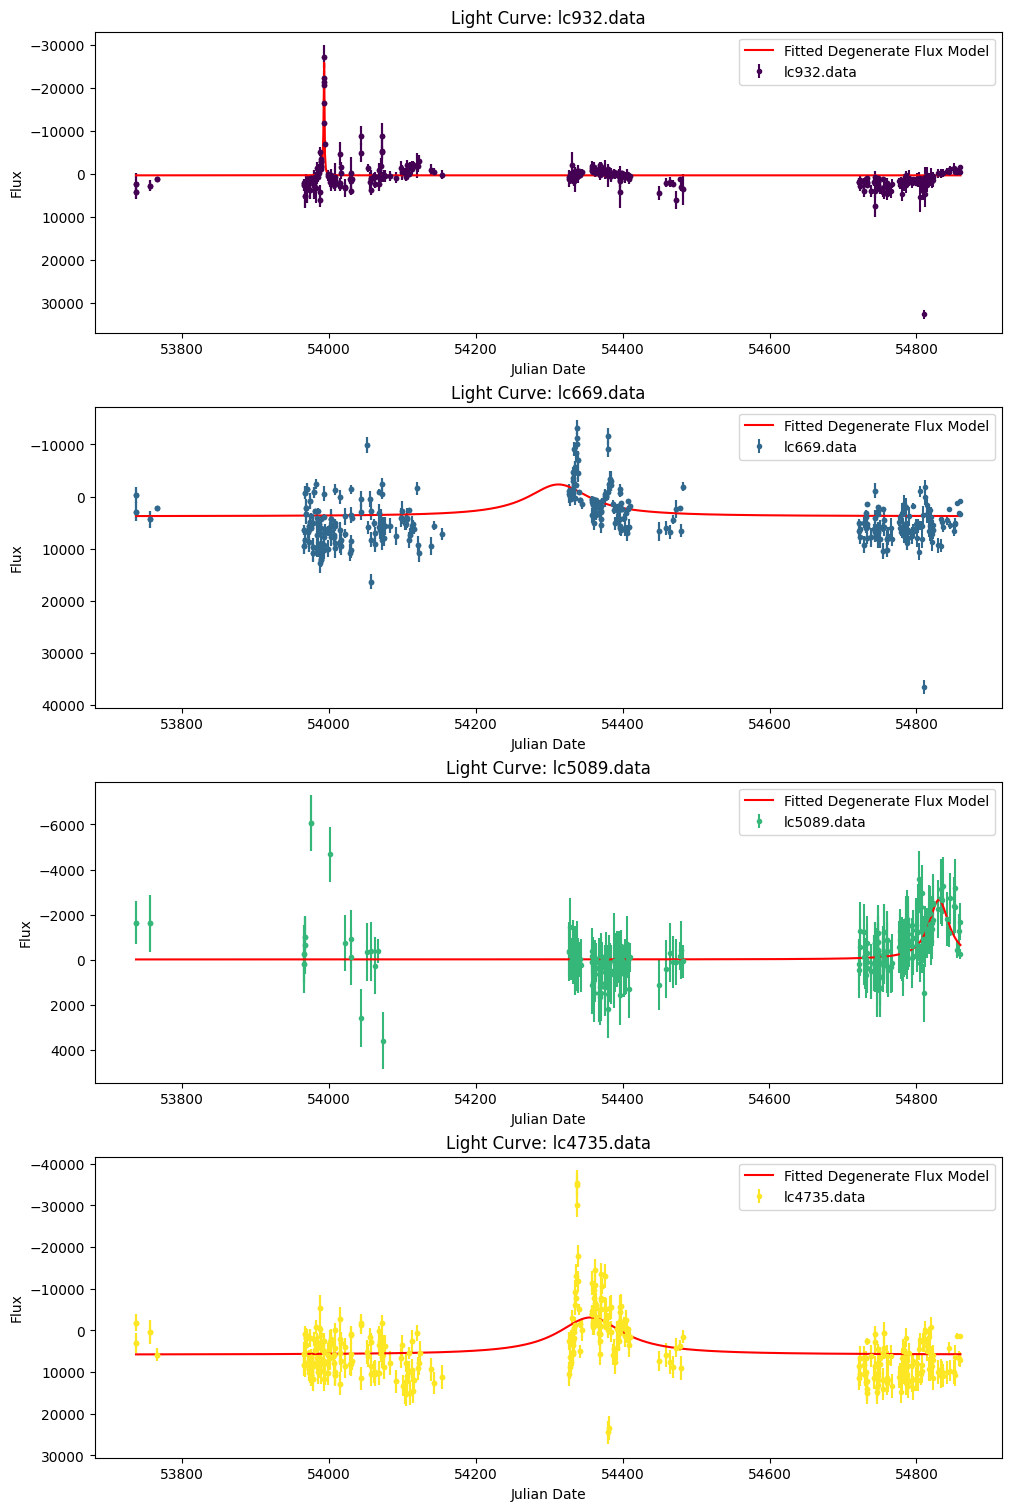

In [ ]:
from scipy import stats

def D_flux_fit(t,t_0,delta_F_0,F_base,t_half):
    F_t=F_base+delta_F_0/(1+12*((t-t_0)/t_half)**2)
    return F_t

def chi_squared(observed, expected, error):
    return np.sum(((observed - expected) / error) ** 2)

dfs=getting_light_curves()
# keys=['lc4735.data', 'lc5089.data', 'lc669.data', 'lc932.data']
# sorted_keys = sorted(keys, key=lambda x: int(x[2:-5]))
# dfs = {k: dfs[k] for k in sorted_keys}
fig,ax=plt.subplots(4,figsize=(10,15),layout='constrained')
colors_viridis=plt.cm.viridis(np.linspace(0,1,len(ax)))
p_0=[[
    54000,     # t_0: event time ~ middle of dataset
    30000,                          # delta_F_0: flux difference at peak
    1000,                           # F_base: baseline flux
    20        # t_half: half-maximum time (days)
],[
    54300,     # t_0: event time ~ middle of dataset
    -10000,                          # delta_F_0: flux difference at peak
    5000,                           # F_base: baseline flux
    10        # t_half: half-maximum time (days)
],
[
    54800.000,     # t_0: event time ~ middle of  dataset
    10000,                          # delta_F_0: flux difference at peak
    800,                           # F_base: baseline flux
    3        # t_half: half-maximum time (days)
],[
    54300.000,     # t_0: event time ~ middle of dataset
    -40000,                          # delta_F_0: flux difference at peak
    9000,                           # F_base: baseline flux
    5        # t_half: half-maximum time (days)
]
]
for i,(name,df) in enumerate(dfs.items()):
    df=df[df['Error'].notna()]
    plotting_light_curves(ax[i],df,name,color=colors_viridis[i],error_multiplier=2)
    p0=p_0[i]
    try:
        ax[i].yaxis.set_inverted(True)
        t_fit = np.linspace(df['Julian_Date'].min(), df['Julian_Date'].max(), 1000)
        popt, pcov = curve_fit(D_flux_fit, df['Julian_Date'], df['Flux'], p0=p0,sigma=df['Error'], absolute_sigma=True, maxfev=10000)
        ax[i].plot(t_fit, D_flux_fit(t_fit, *popt), 'r-', label='Fitted Degenerate Flux Model')
        ax[i].legend()
        print(f"Fitted parameters for {name}:\n t_0, delta_F_0, F_base, t_half {popt}")
        print('errors:', np.sqrt(np.diag(pcov)))
        chi_squared_total=0
        for j in df.index:
            chi = chi_squared(df['Flux'][j], D_flux_fit(df['Julian_Date'][j], *popt), df['Error'][j])
            chi_squared_total += chi
        print(f"Chi-squared for {name}: {chi_squared_total}, Reduced Chi-squared: {chi_squared_total / (len(df) - len(popt))}\n")
    except RuntimeError as e:
        print(f"Could not fit data for {name}: {e}")


# mass calculation

In [ ]:
def mass_Calc(D_s,D_L,v_rel,t_E):
    """Calculate the mass of the lensing object using the Einstein radius crossing time."""
    G = 6.67430e-11  # gravitational constant in m^3 kg^-1 s^-2
    c = 299792458    # speed of light in m/s
    D_s_m = D_s * 3.086e+19  # convert kpc to meters
    D_L_m = D_L * 3.086e+19  # convert kpc to meters
    D_LS_m = (D_s - D_L) * 3.086e+19  # convert kpc to meters
    t_E_s = t_E * 86400  # convert days to seconds
    v_rel_m_s = v_rel * 1000  # convert km/s to m/s

    D_m=D_s_m*D_L_m/(D_s_m-D_L_m)
    M=c**2*D_m*t_E_s**2*v_rel_m_s**2/(4*G*D_L_m**2)

    # theta_E = (v_rel_m_s * t_E_s) / D_L_m  # Einstein radius in radians
    # M = (c**2 / (4 * G)) * (D_L_m * D_LS_m / D_s_m) * theta_E**2  # mass in kg
    M_solar = M / 1.989e+30  # convert kg to solar masses
    return M_solar

def errors(D_s,D_L,v_rel,t_E,delta_D_L,delta_v_rel,delta_t_E,M):
    """Calculate the error in the mass of the lensing object using error propagation."""
    return np.sqrt(((delta_D_L)/(D_L))**2 + ((delta_D_L)/(D_s-D_L))**2 + 2*((delta_t_E)/t_E)**2 + 2*((delta_v_rel)/v_rel)**2)*M

M=mass_Calc(8,5,50,21.28)
print(f"Mass of lensing object: {M} solar masses")
delta_M=errors(8,5,50,21.28,2,30,1.436,M)
print(f"Error in mass of lensing object: {delta_M} solar masses\n")

M=mass_Calc(8,5,50,20.47)
print(f"Mass of lensing object: {M} solar masses")
delta_M=errors(8,5,50,21.28,2,30,2.875,M)
print(f"Error in mass of lensing object: {delta_M} solar masses\n")


# delta_M=errors(8,5,50,21.28,2,30,2.875,M)
# print(f"Error in mass of lensing object: {delta_M} solar masses")



Mass of lensing object: 0.024720340862291194 solar masses
Error in mass of lensing object: 0.02854693007127182 solar masses

Mass of lensing object: 0.022874251557341498 solar masses
Error in mass of lensing object: 0.02668505022897852 solar masses

Mass of lensing object: 0.017206010876139047 solar masses


In [5]:
import numpy as np
def mass_Calc(D_s,D_L,Delta_D,v_rel,t_E):
    """Calculate the mass of the lensing object using the Einstein radius crossing time."""
    G = 6.67430e-11  # gravitational constant in m^3 kg^-1 s^-2
    c = 299792458    # speed of light in m/s
    D_s_m = D_s * 3.086e+19  # convert kpc to meters
    D_L_m = D_L * 3.086e+19  # convert kpc to meters
    D_LS_m = Delta_D * 3.086e+19  # convert kpc to meters
    t_E_s = t_E * 86400  # convert days to seconds
    v_rel_m_s = v_rel * 1000  # convert km/s to m/s

    D_m=D_s_m*D_L_m/D_LS_m
    M=c**2*D_m*t_E_s**2*v_rel_m_s**2/(4*G*D_L_m**2)

    # theta_E = (v_rel_m_s * t_E_s) / D_L_m  # Einstein radius in radians
    # M = (c**2 / (4 * G)) * (D_L_m * D_LS_m / D_s_m) * theta_E**2  # mass in kg
    M_solar = M / 1.989e+30  # convert kg to solar masses
    return M_solar

def errors(Delta_D,v_rel,t_half,delta_Delta_D,delta_v_rel,delta_t_half,M):
    """Calculate the error in the mass of the lensing object using error propagation."""
    return np.sqrt(((delta_Delta_D)/(Delta_D))**2 + 2*((delta_t_half)/t_half)**2 + 2*((delta_v_rel)/v_rel)**2)*M

def t_E(t_half,A_0):
    return t_half*A_0/2*np.sqrt(3)

M=mass_Calc(780,780,2,130,t_E(57.5,10))
print(f"Mass of lensing object: {M} solar masses")
delta_M=errors(2,130,57.5,1,50,6.18,M)
print(f"Error in mass of lensing object: {delta_M} solar masses\n")

Mass of lensing object: 85.7879189287091 solar masses
Error in mass of lensing object: 64.7094093551626 solar masses

